# **My work consit to build a Convolutionnal Neural Network + Long-short Term memory model to predict a Human Activity Recognition using UCF50 dataset**.
## we are going to follow these steps
- Step 1: Download and Visualize the Data with its Labels
- Step 2: Preprocess the Dataset
- Step 3: Split the Data into Train and Test Set
- Step 5: implement the LRCN Approach
  - Step 5.1: Construct the Model
  - Step 5.2: Compile & Train the Model
  - Step 5.3: Plot Model’s Loss & Accuracy Curves
  - step 5.4: Download a youtube video for testing
  - step 5.5: Perform the prediction on the video



In [ ]:


pip install pafy


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Import the required libraries.**

In [ ]:
# Import the required libraries.
import os
import cv2
#import pafy
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt

from moviepy import *
%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.layers import (TimeDistributed, Conv2D, MaxPooling2D,
                                     Dropout, Flatten, LSTM, Dense)
from tensorflow.keras import Input


# **Preprocess the Dataset**

In [ ]:
# Veri setimizde her video karesinin yeniden boyutlandırılacağı yüksekliği ve genişliği belirtin.
image_height , image_width = 64, 64

# Modele tek bir dizi olarak beslenecek videonun kare sayısını belirtin.
sequence_length = 25

# UCF50 veri kümesini içeren dizini belirtin.
DATASET_DIR = "/content/drive/ MyDrive/TheGeek/HAR/dataset"
# Eğitim için kullanılan sınıfların adlarını içeren listeyi belirtin. Herhangi bir sınıf kümesini seçmekten çekinmeyin.
CLASSES_LIST = [ "Basketball", "SkateBoarding", "Skiing", "HorseRiding", "RockClimbingIndoor"]

# **Extracts a specified number of equally spaced frames from a video, resizes and normalizes it.**
# Argr:


*   video_path (str): Video dosyasının yolu.

*   sequence_length (int): Çıkarılacak kare sayısı.
*   image_height (int): Hedef kare yüksekliği.


*  image_width (int): Hedef kare genişliği.






Döndürür:
List[np.ndarray]: Önceden işlenmiş karelerin listesi (numpy dizileri olarak).

# **Create a Function to Extract, Resize & Normalize Frames**

We will create a function extract_frames() that will create a list containing the resized and normalized frames of a video

In [ ]:

def extract_frames(video_path, sequence_length, image_height, image_width):

    frames_list = []

    # Open video file
    video_capture = cv2.VideoCapture(video_path)
    if not video_capture.isOpened():
        raise IOError(f"Cannot open video file: {video_path}")

    total_frames = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        video_capture.release()
        raise ValueError("Video contains no frames.")

    # Determine the interval to skip between frames
    skip_interval = max(total_frames // sequence_length, 1)

    for i in range(sequence_length):
        # Set the frame position
        frame_index = i * skip_interval
        video_capture.set(cv2.CAP_PROP_POS_FRAMES, frame_index)

        success, frame = video_capture.read()
        if not success:
            print(f"Warning: Could not read frame at index {frame_index}")
            break

        # Resize and normalize the frame
        frame_resized = cv2.resize(frame, (image_width, image_height))
        frame_normalized = frame_resized.astype(np.float32) / 255.0

        frames_list.append(frame_normalized)

    video_capture.release()

    if len(frames_list) < sequence_length:
        print(f"Warning: Only {len(frames_list)} frames extracted out of {sequence_length} requested.")

    return frames_list


# **Seçili sınıfların videolarından kareleri çıkararak ve ön işleme tabi tutarak bir veri kümesi oluşturur**.

# Argümanlar:
- dataset_dir (str): Video dosyaları içeren sınıf adlı alt klasörleri
içeren kök dizin.
- classes_list (List[str]): Sınıfların adları (klasör adlarıyla eşleşmelidir).
- sequence_length (int): Video başına çıkarılacak kare sayısı.
- image_height (int): Yeniden boyutlandırılan kareler için hedef yükseklik.
- image_width (int): Yeniden boyutlandırılan kareler için hedef genişlik.

# Döndürür:
Tuple[np.ndarray, np.ndarray, List[str]]:
- features: Çıkarılan ve normalleştirilmiş kare dizilerinin dizisi (şekil: [num_samples, sequence_length, H, W, C]).
- labels: Her videonun sınıfına karşılık gelen tam sayı etiketlerinin dizisi.
- video_paths: Kullanılan videolara giden tam yolların listesi.

In [ ]:

def create_dataset(dataset_dir, classes_list, sequence_length, image_height, image_width):

    features = []
    labels = []
    video_paths = []

    for class_index, class_name in enumerate(classes_list):
        class_dir = os.path.join(dataset_dir, class_name)
        if not os.path.isdir(class_dir):
            print(f"Warning: Directory for class '{class_name}' not found. Skipping.")
            continue

        print(f"Processing class '{class_name}'...")

        for file_name in os.listdir(class_dir):
            if not file_name.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
                continue  # Ignore non-video files

            video_path = os.path.join(class_dir, file_name)

            try:
                frames = extract_frames(video_path, sequence_length, image_height, image_width)
                if len(frames) == sequence_length:
                    features.append(frames)
                    labels.append(class_index)
                    video_paths.append(video_path)
                else:
                    print(f"Skipping video '{file_name}' due to insufficient frames.")
            except Exception as e:
                print(f"Error processing '{video_path}': {e}")

    if not features:
        raise RuntimeError("No valid video data found. Please check the dataset directory and class structure.")

    features = np.array(features, dtype=np.float32)
    labels = np.array(labels, dtype=np.int64)

    return features, labels, video_paths


In [ ]:
features, labels, video_paths = create_dataset(
    DATASET_DIR, CLASSES_LIST, sequence_length, image_height, image_width
)


Processing class 'Basketball'...
Processing class 'SkateBoarding'...
Processing class 'Skiing'...
Processing class 'HorseRiding'...
Processing class 'RockClimbingIndoor'...


In [ ]:
# Using Keras's to_categorical method to convert labels into one-hot-encoded vectors
one_hot_encoded_labels = to_categorical(labels)

# **Split the Data into Train and Test Set**

As of now, we have the required features and one_hot_encoded_labels.

In [ ]:
seed_constant = 27
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)
# Split the Data into Train ( 80% ) and Test Set ( 20% ).
features_train, features_test, labels_train, labels_test = train_test_split(features, one_hot_encoded_labels, test_size = 0.20, shuffle = True, random_state = seed_constant)

# **Creates a Long-term Recurrent Convolutional Network (LRCN) model for video classification using CNN + LSTM architecture**.

#Arguments:

- sequence_length (int): Number of frames per video.
- image_height (int): Height of input frames.
- image_width (int): Width of input frames.
- num_classes (int): Number of output classes.

Returns:
  - model (Sequential): Compiled LRCN model.

In [ ]:


def create_LRCN_model(sequence_length, image_height, image_width, num_classes):

    model = Sequential(name="LRCN_Model")

    # Input shape for the model: (sequence_length, height, width, channels)
    input_shape = (sequence_length, image_height, image_width, 3)

    # Convolutional layers (wrapped in TimeDistributed to process each frame)
    model.add(TimeDistributed(Conv2D(16, (3, 3), padding='same', activation='relu'), input_shape=input_shape))
    model.add(TimeDistributed(MaxPooling2D(pool_size=(4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(32, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D(pool_size=(4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))
    model.add(TimeDistributed(Dropout(0.25)))

    # Flatten the features of each frame before passing to LSTM
    model.add(TimeDistributed(Flatten()))

    # LSTM layer to learn temporal patterns
    model.add(LSTM(64))  # You can increase this for more temporal capacity

    # Fully connected output layer
    model.add(Dense(num_classes, activation='softmax'))

    # Summary of the model architecture
    model.summary()

    return model


In [ ]:
num_classes = len(CLASSES_LIST)
# Construct the required LRCN model.
LRCN_model = create_LRCN_model(sequence_length, image_height, image_width, num_classes)

# Display the success message.
print("Model Created Successfully!")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LRCN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 25, 64, 64, 16) │           448 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 25, 16, 16, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 25, 16, 16, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 25, 16, 16, 32) │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 25, 4, 4, 32)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 25, 4, 4, 32)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 25, 4, 4, 64)   │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 25, 2, 2, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 25, 2, 2, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 25, 2, 2, 64)   │        36,928 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 25, 1, 1, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 25, 1, 1, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 25, 64)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,861 (366.64 KB)

 Trainable params: 93,861 (366.64 KB)

 Non-trainable params: 0 (0.00 B)

Model Created Successfully!


# **Compile & Train the Model**

After checking the structure, we will compile and start training the model.

In [ ]:

# Predefine callback to avoid overfitting
early_stopping = EarlyStopping(
              monitor='val_loss',                     # Monitor the validation status
              patience=15,                            # Number of epochs that were not optimized before being arrested
              mode='min',                             # Calculate the value of the minimum value lost
              restore_best_weights=True                # Restores the model's optimal weights
)

# Compiling the LRCN model
LRCN_model.compile(
    loss='categorical_crossentropy',   # Since labels are one-hot coded
    optimizer=Adam(),                  # An efficient and widely used optimizer
    metrics=['accuracy']              # To monitor performance
)

# Model training
history = LRCN_model.fit(
    x=features_train,
    y=labels_train,
    epochs=100,
    batch_size=4,
    shuffle=True,
    validation_split=0.2,              # Verilerin %20'sini doğrulama için kullanın
    callbacks=[early_stopping],        # Erken durdurmayı ekler
    verbose=1                          # Eğitim sırasında günlükleri görüntüler
)

print("Eğitim bitti.")


Epoch 1/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 121s 767ms/step - accuracy: 0.2686 - loss: 1.6184 - val_accuracy: 0.2250 - val_loss: 1.5959
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 86s 719ms/step - accuracy: 0.3736 - loss: 1.4704 - val_accuracy: 0.4667 - val_loss: 1.3428
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 141s 713ms/step - accuracy: 0.4962 - loss: 1.2749 - val_accuracy: 0.5083 - val_loss: 1.2355
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 86s 722ms/step - accuracy: 0.5671 - loss: 1.1024 - val_accuracy: 0.5833 - val_loss: 1.1539
Epoch 5/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 139s 697ms/step - accuracy: 0.5949 - loss: 1.0396 - val_accuracy: 0.5667 - val_loss: 1.1298
Epoch 6/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 144s 721ms/step - accuracy: 0.7011 - loss: 0.9821 - val_accuracy: 0.6167 - val_loss: 0.9888
Epoch 7/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 142s 724ms/step - accuracy: 0.7013 - loss: 0.8224 - val_accuracy: 0.6417 - val_loss: 0.9278
Epoch 8/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 144s 742ms/step - accuracy: 0.

# **Evaluating the trained Model**

As done for the previous one, we will evaluate the LRCN model on the test set.

In [ ]:
# Evaluate the trained model.
model_evaluation_history = LRCN_model.evaluate(features_test, labels_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 975ms/step - accuracy: 0.8507 - loss: 0.5412


# **Save Model**

After that, we will save the model for future uses using the same technique we had used for the previous model.

In [ ]:
# Extract the loss and accuracy of the model after evaluation
evaluation_loss, evaluation_accuracy = model_evaluation_history

# Create a  timestamp for the file name
timestamp = dt.datetime.now().strftime('%Y_%m_%d__%H_%M_%S')

# Format numeric values ​​to be clean in the file name
formatted_loss = f"{evaluation_loss:.4f}"
formatted_accuracy = f"{evaluation_accuracy:.4f}"

#Build an explicit file name
model_filename = f"LRCN_model__{timestamp}__Loss_{formatted_loss}__Acc_{formatted_accuracy}.h5"

#Create a backup folder if it doesn't exist
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

#Full backup path
model_path = os.path.join(save_dir, model_filename)

# Saving the model
LRCN_model.save(model_path)
print(f"Model şu şekilde kaydedildi : {model_path}")

Model şu şekilde kaydedildi : saved_models/LRCN_model__2025_05_28__20_30_49__Loss_0.5890__Acc_0.8333.h5


#**Displays the evolution curve of a training and validation metric**.

Args:
- history (History): The object returned by model.fit().
- train_metric (str): Name of the training metric (e.g., 'loss', 'accuracy').
- val_metric (str): Name of the validation metric (e.g., 'val_loss', 'val_accuracy').
- title (str): Title of the graph.

In [ ]:
import matplotlib.pyplot as plt

def plot_metric(history, train_metric, val_metric, title):

    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_metric], label=f"Train {train_metric}")
    plt.plot(history.history[val_metric], label=f"Validation {val_metric}")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel(train_metric.capitalize())
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


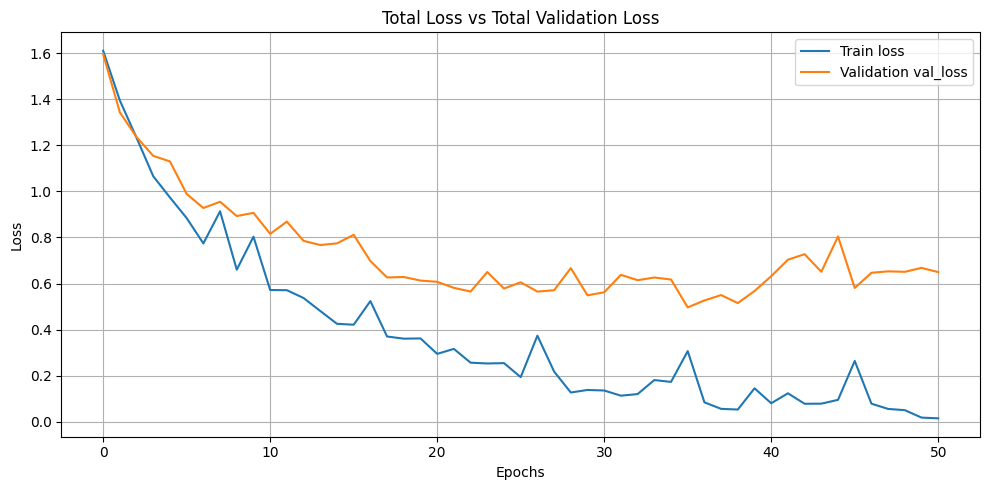

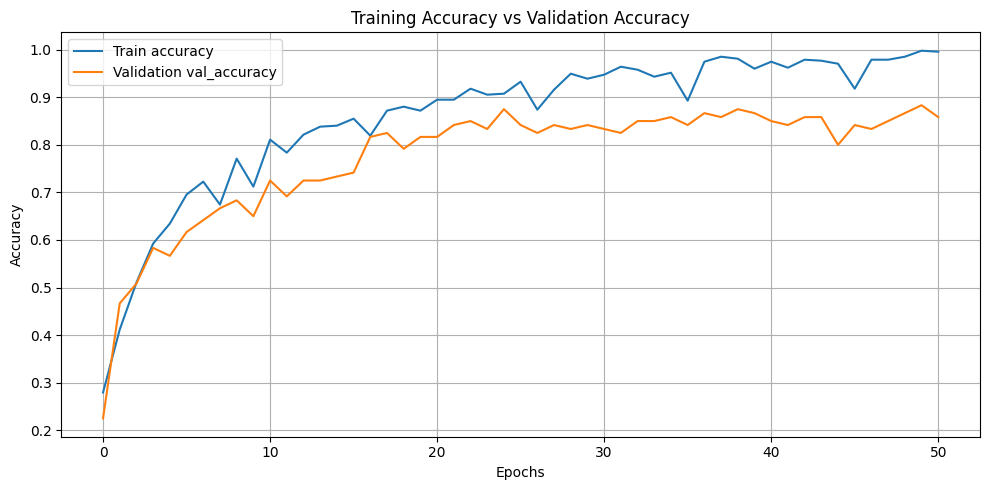

In [ ]:
plot_metric(history, 'loss', 'val_loss', 'Total Loss vs Total Validation Loss')
plot_metric(history, 'accuracy', 'val_accuracy', 'Training Accuracy vs Validation Accuracy')


In [ ]:
from google.colab import files



In [ ]:
# Installation
!pip install yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 43.2 MB/s eta 0:00:00


In [ ]:
import os
import glob
from yt_dlp import YoutubeDL
import cv2

# Fixed function to download and return exact file path
def download_youtube_video_fixed(youtube_url, output_dir):
    """
    Downloads a YouTube video and returns the exact path of the downloaded file.

          Args:
          youtube_url (str): URL of the YouTube video
          output_dir (str): Destination directory

          Returns:
    str: Full path of the downloaded file, or None on failure
    """
    os.makedirs(output_dir, exist_ok=True)

    # List files before downloading
    files_before = set(os.listdir(output_dir))

    ydl_opts = {
        'format': 'best[height<=720]/best',
        'outtmpl': os.path.join(output_dir, '%(title)s.%(ext)s'),
        'quiet': False,
        'no_warnings': False
    }

    try:
        with YoutubeDL(ydl_opts) as ydl:
            print(f"[INFO] Téléchargement de : {youtube_url}")
            info = ydl.extract_info(youtube_url, download=True)

        # # List files after downloading
        files_after = set(os.listdir(output_dir))
        new_files = files_after - files_before

        if new_files:
            # Take the first new file (should be our video)
            downloaded_file = list(new_files)[0]
            full_path = os.path.join(output_dir, downloaded_file)
            print(f"[SUCCESS] File downloaded: {full_path}")
            return full_path
        else:
            print("[ERROR] No new files detected after download")
            return None

    except Exception as e:
        print(f"[ERROR] Error while downloading: {e}")
        return None

# Function to automatically find video files
def find_video_files(directory):

    if not os.path.exists(directory):
        return []

    video_extensions = ['*.mp4', '*.avi', '*.mov', '*.mkv', '*.webm', '*.m4v']
    video_files = []

    for extension in video_extensions:
        pattern = os.path.join(directory, extension)
        video_files.extend(glob.glob(pattern))

    return video_files

# Corrected function for prediction
def predict_single_action_fixed(video_file_path, sequence_length):

    # Vérifier l'existence du fichier
    if not os.path.exists(video_file_path):
        print(f"[ERROR] File does not exist:{video_file_path}")
        return False

    # Check file size
    file_size = os.path.getsize(video_file_path)
    print(f"[INFO] File size : {file_size} bytes")

    if file_size == 0:
        print("[ERROR] The file is empty")
        return False

    # Initialize video capture
    video_reader = cv2.VideoCapture(video_file_path)
    if not video_reader.isOpened():
        print(f"[ERROR] Unable to open video : {video_file_path}")
        return False

    # Get video information
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = video_reader.get(cv2.CAP_PROP_FPS)
    duration = video_frames_count / fps if fps > 0 else 0

    print(f"[INFO] Totals Frames  : {video_frames_count}")
    print(f"[INFO] FPS : {fps}")
    print(f"[INFO] Time : {duration:.2f} secondes")

    if video_frames_count < sequence_length:
        print(f"[ERROR] Video too short : {video_frames_count} frames < {sequence_length} require")
        video_reader.release()
        return False

    frames_list = []
    skip_frames_window = max(int(video_frames_count / sequence_length), 1)

    print(f"[INFO] Jump interval : {skip_frames_window}")

    #  Frames extraction
    for frame_counter in range(sequence_length):
        frame_position = frame_counter * skip_frames_window
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_position)
        success, frame = video_reader.read()

        if not success:
            print(f"[WARNING] Unable to read frame {frame_position}")
            continue

        # Resize and normalize
        resized_frame = cv2.resize(frame, (image_width, image_height))
        normalized_frame = resized_frame / 255
        frames_list.append(normalized_frame)

    video_reader.release()

    print(f"[INFO] Frames successfully extracted : {len(frames_list)}/{sequence_length}")

    # Prediction
    if len(frames_list) == sequence_length:
        try:
            input_tensor = np.expand_dims(frames_list, axis=0)
            predicted_labels_probabilities = LRCN_model.predict(input_tensor, verbose=0)[0]
            predicted_label = np.argmax(predicted_labels_probabilities)
            predicted_class_name = CLASSES_LIST[predicted_label]
            confidence = predicted_labels_probabilities[predicted_label]

            print(f"\n{'='*50}")
            print(f"PREDICTION RESULT")
            print(f"{'='*50}")
            print(f"Predicted action : {predicted_class_name}")
            print(f"Trust : {confidence:.3f} ({confidence*100:.1f}%)")
            print(f"\nAll scores :")
            for i, class_name in enumerate(CLASSES_LIST):
                score = predicted_labels_probabilities[i]
                print(f"  {class_name:20} : {score:.3f} ({score*100:.1f}%)")
            print(f"{'='*50}")

            return True

        except Exception as e:
            print(f"[ERROR] Error while predicting : {e}")
            return False
    else:
        print(f"[ERROR] Insufficient number of frames : {len(frames_list)}/{sequence_length}")
        return False

# main pipeline code
def main_prediction_pipeline():
    """
    Complete download and prediction pipeline.
    """
    test_videos_directory = 'test_videos'
    youtube_url = 'https://youtu.be/fc3w827kwyA'

    print("="*60)
    print("START OF THE PREDICTION PIPELINE")
    print("="*60)

    # 1. Télécharger la vidéo
    print("\n[STEP 1] Downloading YouTube Video...")
    downloaded_file_path = download_youtube_video_fixed(youtube_url, test_videos_directory)

    if not downloaded_file_path:
        print("[ERROR] Download failed")
        return

    # 2. Vérifier les fichiers disponibles
    print(f"\n[STEP 2] Checking the files in {test_videos_directory}...")
    video_files = find_video_files(test_videos_directory)

    if not video_files:
        print("[ERROR] No video files found")
        return

    print("Available video files:")
    for i, file_path in enumerate(video_files):
        file_size = os.path.getsize(file_path)
        print(f"  {i+1}. {os.path.basename(file_path)} ({file_size} bytes)")

    #3. Use the downloaded or most recent file
    target_video = downloaded_file_path if os.path.exists(downloaded_file_path) else video_files[0]

    print(f"\n[STEP 3] Prediction on : {os.path.basename(target_video)}")
    success = predict_single_action_fixed(target_video, sequence_length)

    #4. Try to view the video
    if success:
        print(f"\n[STEP 4] Trying to display the video...")
        try:
            from moviepy.editor import VideoFileClip
            clip = VideoFileClip(target_video, audio=False, target_resolution=(300, None))
            clip.ipython_display()
            print("[SUCCESS] Video successfully displayed")
        except Exception as e:
            print(f"[WARNING] Unable to display video : {e}")
            print("The prediction was successful, but the display failed")

    print("\n" + "="*60)
    print("END OF THE PIPELINE")
    print("="*60)

# Run the pipeline
main_prediction_pipeline()

START OF THE PREDICTION PIPELINE

[STEP 1] Downloading YouTube Video...
[INFO] Téléchargement de : https://youtu.be/fc3w827kwyA
[youtube] Extracting URL: https://youtu.be/fc3w827kwyA
[youtube] fc3w827kwyA: Downloading webpage
[youtube] fc3w827kwyA: Downloading tv client config
[youtube] fc3w827kwyA: Downloading tv player API JSON
[youtube] fc3w827kwyA: Downloading ios player API JSON
[youtube] fc3w827kwyA: Downloading m3u8 information
[info] fc3w827kwyA: Downloading 1 format(s): 18
[download] Destination: test_videos/Comparison of Four Styles of Tai Chi.mp4
[download] 100% of    6.57MiB in 00:00:01 at 4.13MiB/s   
[SUCCESS] File downloaded: test_videos/Comparison of Four Styles of Tai Chi.mp4

[STEP 2] Checking the files in test_videos...
Available video files:
  1. Comparison of Four Styles of Tai Chi.mp4 (6886419 bytes)

[STEP 3] Prediction on : Comparison of Four Styles of Tai Chi.mp4
[INFO] File size : 6886419 bytes
[INFO] Totals Frames  : 6220
[INFO] FPS : 29.97002997002997
[INFO]

t: 100%|█████████▉| 6216/6221 [00:26<00:00, 297.12it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.11/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarning: Warning: in file test_videos/Comparison of Four Styles of Tai Chi.mp4, 360000 bytes wanted but 0 bytes read,at frame 6220/6221, at time 207.54/207.56 sec. Using the last valid frame instead.
  warnings.warn("Warning: in file %s, "%(self.filename)+

                                                                 

Moviepy - Done !
Moviepy - video ready __temp__.mp4
[WARNING] Unable to display video : The duration of video __temp__.mp4 (207.6) exceeds the 'maxduration' attribute. You can increase 'maxduration', by passing 'maxduration' parameterto ipython_display function.But note that embedding large videos may take all the memory away !
The prediction was successful, but the display failed

END OF THE PIPELINE


Having completed my work, I was able to train and assemble a Deep Learning model combining Convolutional Neural Networks and Long Short Term Memory to predict and recognize human activities. The model was trained on the UCF50 dataset over 100 epochs in batches of 4 and a separation of 20% for the test and 80% for the training. We obtain a validation of the accuracy at 99% and a loss of 0.2% which largely satisfies us. Thanks to Earlystopping we were able to avoid overfitting by stopping at epoch 51. The evaluation of the model's history shows us an accuracy of 85% and a loss of 54%. We have got a prdiction on our video.
- the resume:

 [STEP 3] Prediction on : Comparison of Four Styles of Tai Chi.mp4
 - [INFO] File size : 6886419 bytes
 - [INFO] Totals Frames  : 6220
 - [INFO] FPS : 29.97002997002997
 - [INFO] Time : 207.54 secondes
 - [INFO] Jump interval : 248
 - [INFO] Frames successfully extracted : 25/25